____
# Colocalization dataset
- put all variables for reconstruction in the same file


In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import swot_dir, drifters_dir, get_proj, lonlat2xy, zarr_dir, surface_drifters, depth_drifters, depth_100, depth_50, images_dir, U2, err_acc
from swot import browse_swot_250, add_mask_inside_swot, build_swath_polygon
from diagnosis import dataset_coloc_combs, DRIFTER, ALTI, WD

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo
crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

_______
# Data

In [2]:
DRIFTER.keys(), ALTI.keys(), WD.keys()
# wd_depth = '0' or '15'
# ggd_var = 'etaf', 'etac', 'adtf', 'adtc', 'fromduacsv'

(dict_keys(['nofilter', '0.5cpd', '1.5cpd', '2.5cpd', '3cpd']),
 dict_keys(['swot250naive', 'swot250gauss1e3', 'swot250gauss2e3', 'swot250gauss3e3', 'swot250gauss4e3', 'swot250gauss5e3', 'swot2kmnaive', 'swot2kmgauss1e3', 'swot2kmgauss2e3', 'swot2kmgauss3e3', 'swot2kmgauss4e3', 'swot2kmgauss5e3', 'swot2kmgauss1e4']),
 dict_keys(['era5']))

In [3]:
def compute_mean_square(ds):
    var = ['acc', 'cor', 'ggd', 'wd','sum']
    VAR = ['ACC', 'COR', 'GGD', 'WD', 'S']
    dss = (ds[[v+'n' for v in var] + [v+'e' for v in var]]**2).mean(dim='row_number').rename({var[i]+'n' : VAR[i]+'n' for i in range(5)}).rename({var[i]+'e' : VAR[i]+'e' for i in range(5)})
    dss['sigmae'] = dss.ACCe + dss.CORe + dss.GGDe + dss.WDe
    dss['sigman'] = dss.ACCn + dss.CORn + dss.GGDn + dss.WDn
    dss['nb_coloc'] = len(ds.row_number)
    #Balanced and error
    for direction in ['e', 'n']:
        for v in ['acc', 'cor', 'ggd', 'wd'] : 
                dss['B'+direction+'_'+v] = -((ds[v+direction]*ds['exc'+direction+'_'+v])).mean(dim='row_number')
                dss['E'+direction+'_'+v] = ((ds[v+direction]*ds['sum'+direction])).mean(dim='row_number')
    #pairs contributions
    for v in [v for v in ds if 'prod' in v]:
        dss[v.replace('prod', 'X')]=-2*ds[v].mean(dim='row_number')
    return dss

_______
# Count 

In [41]:
depth = 0
nc=4 

comb_list = [dict(drifter_key='nofilter', alti_key = 'swot2kmnaive', wd_key = 'era5', ggd_var='etaf', wd_depth='0'), 
            ]
DS = dataset_coloc_combs(comb_list, nearest =False).dropna('row_number').drop_sel(row_number = err_acc)
dfc = pd.read_csv(os.path.join(zarr_dir, f'cluster_{nc}_{depth}m.csv')).set_index('row_number')
dsc = dfc.to_xarray()


nofilter__swot2kmnaive_etaf__rio_0era5


In [42]:
dfc

,datetime,drifter_id,cycle_date,longitude,latitude,pass_number,cycle_number,meanwinde,meanwindn,meanflowe,meanflown,hfe,hfn,cluster
row_number,,,,,,,,,,,,,,
1,2023-04-01 12:00:00,300534060315840,2023-04-01 23:42:32.696536000,4.812432,42.221430,3,478,0.193788,0.158837,0.064724,0.098624,0.002433,0.005040,2
2,2023-04-01 12:10:00,300534060315840,2023-04-01 23:42:32.696536000,4.812916,42.221930,3,478,0.190727,0.155216,0.066192,0.095170,0.003070,0.006964,2
3,2023-04-01 12:20:00,300534060315840,2023-04-01 23:42:32.696536000,4.813418,42.222394,3,478,0.187415,0.151487,0.067420,0.091850,0.003510,0.008742,2
4,2023-04-01 12:30:00,300534060315840,2023-04-01 23:42:32.696536000,4.813933,42.222825,3,478,0.184005,0.147717,0.068422,0.088691,0.003776,0.010355,2
5,2023-04-01 12:40:00,300534060315840,2023-04-01 23:42:32.696536000,4.814456,42.223226,3,478,0.180544,0.143928,0.069212,0.085716,0.003893,0.011784,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
383258,2023-07-10 06:10:00,300534060015760,2023-07-09 18:56:21.868455616,2.417785,39.788394,16,577,0.004790,0.008606,0.038542,0.095014,0.107107,0.106440,3
383259,2023-07-10 06:20:00,300534060015760,2023-07-09 18:56:21.868455616,2.416881,39.788885,16,577,0.005213,0.008740,0.036655,0.096186,0.107657,0.105500,3
383260,2023-07-10 06:30:00,300534060015760,2023-07-09 18:56:21.868455616,2.415948,39.789399,16,577,0.005621,0.008871,0.034789,0.097335,0.108253,0.104624,3


In [43]:
ds = xr.merge([dsc['cluster'], DS]).dropna('row_number')
D = {c : ds.where(ds.cluster==c, drop=True) for c in np.unique(ds.cluster.values)}
Dmean = {c : compute_mean_square(D[c])/U2 for c in np.unique(ds.cluster.values)} 

__________________
## Sensitivity to SWOT-250m filtering

19384
6.30171912754961
6.957971416677783
11.440163982624398
12.013341985024326
23910
8.25521251661042
8.93515817236341
6.478076699469295
6.79242905654845
14589
9.746108280588905
10.115756414874369
7.045309100939303
7.484774378228973
54850
3.008370563656735
3.126732541230073
3.0798861150824255
3.1727199506695714


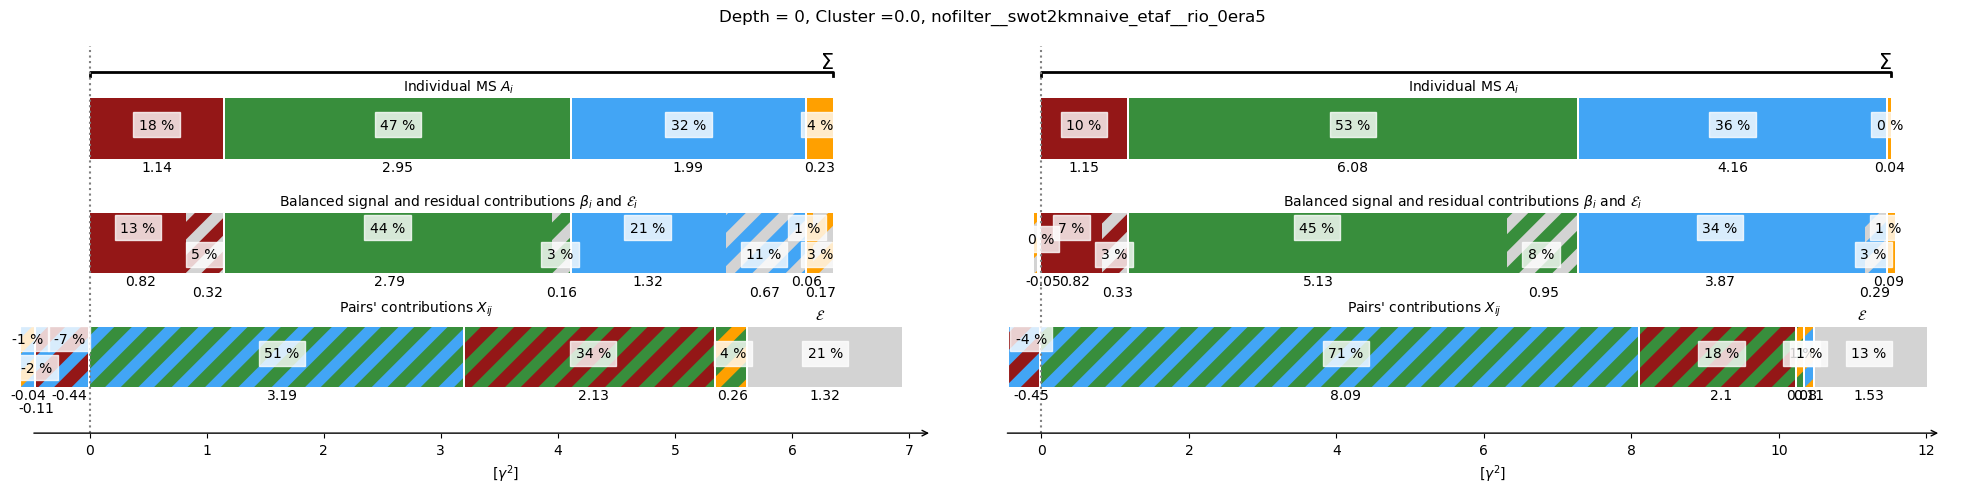

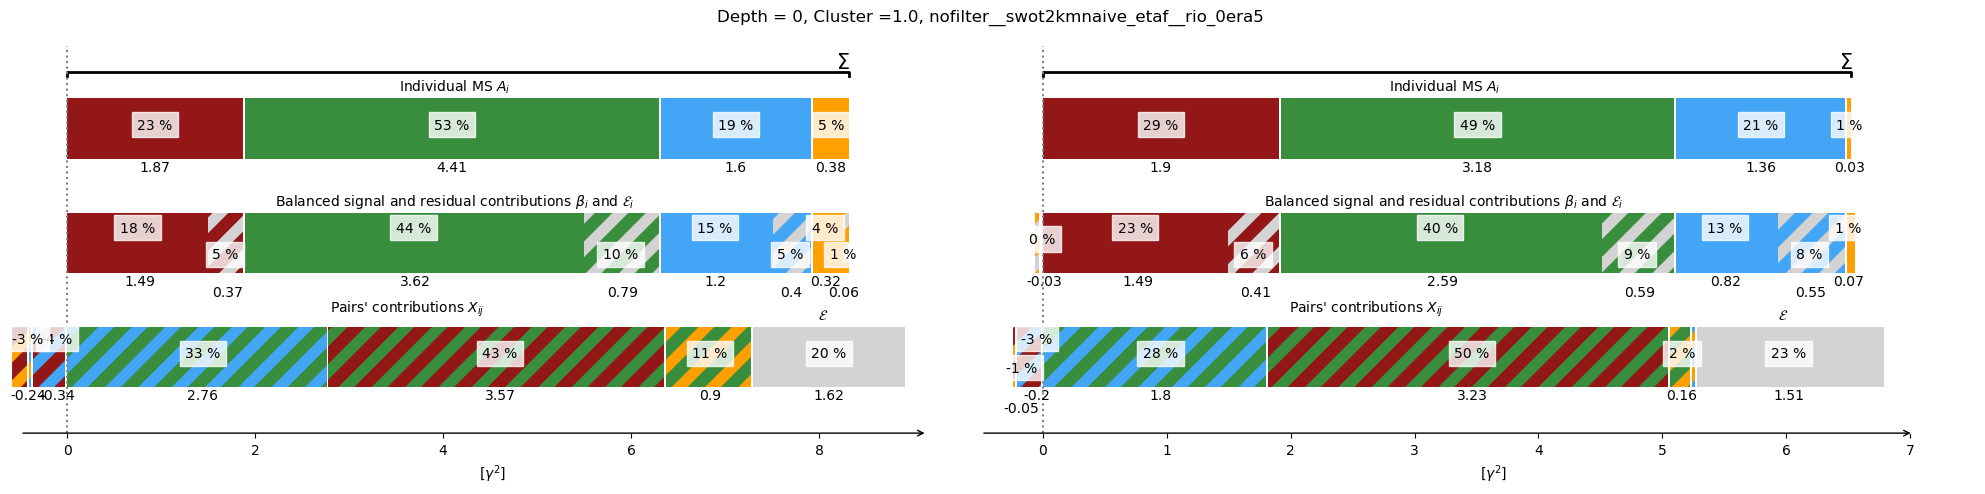

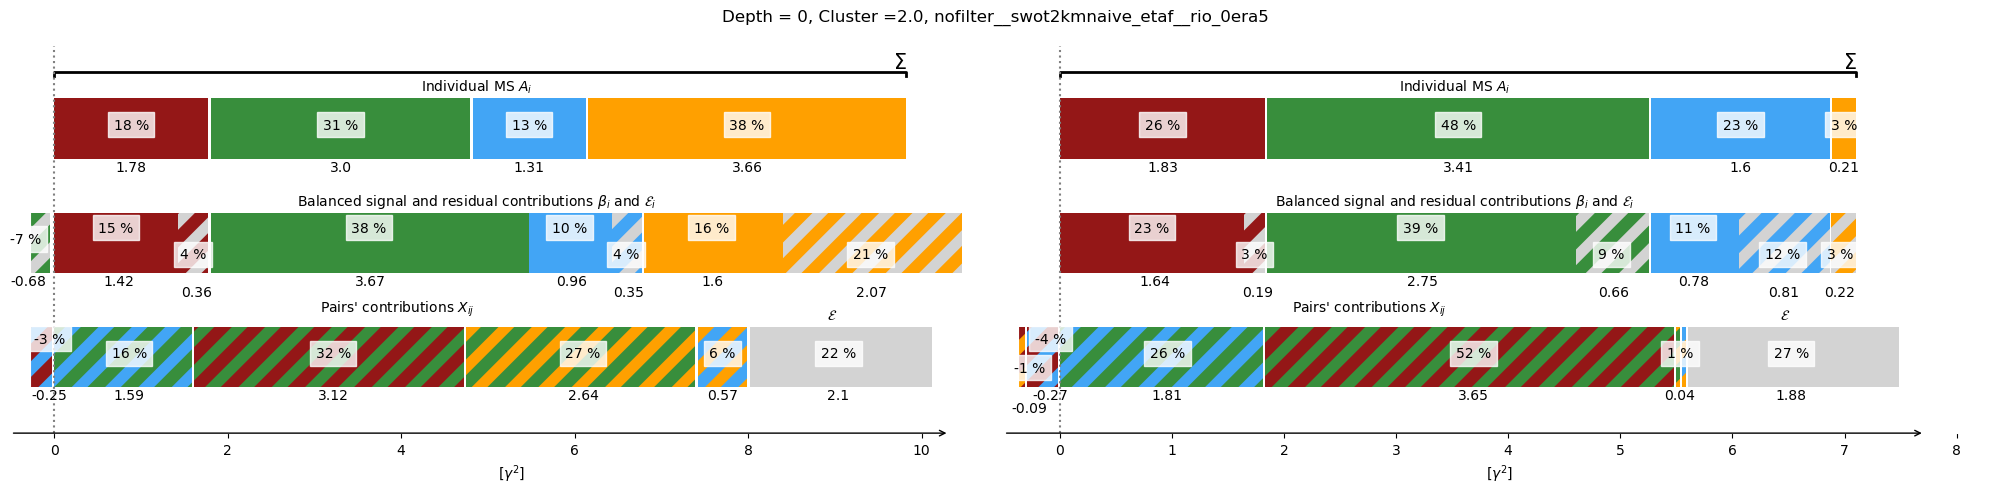

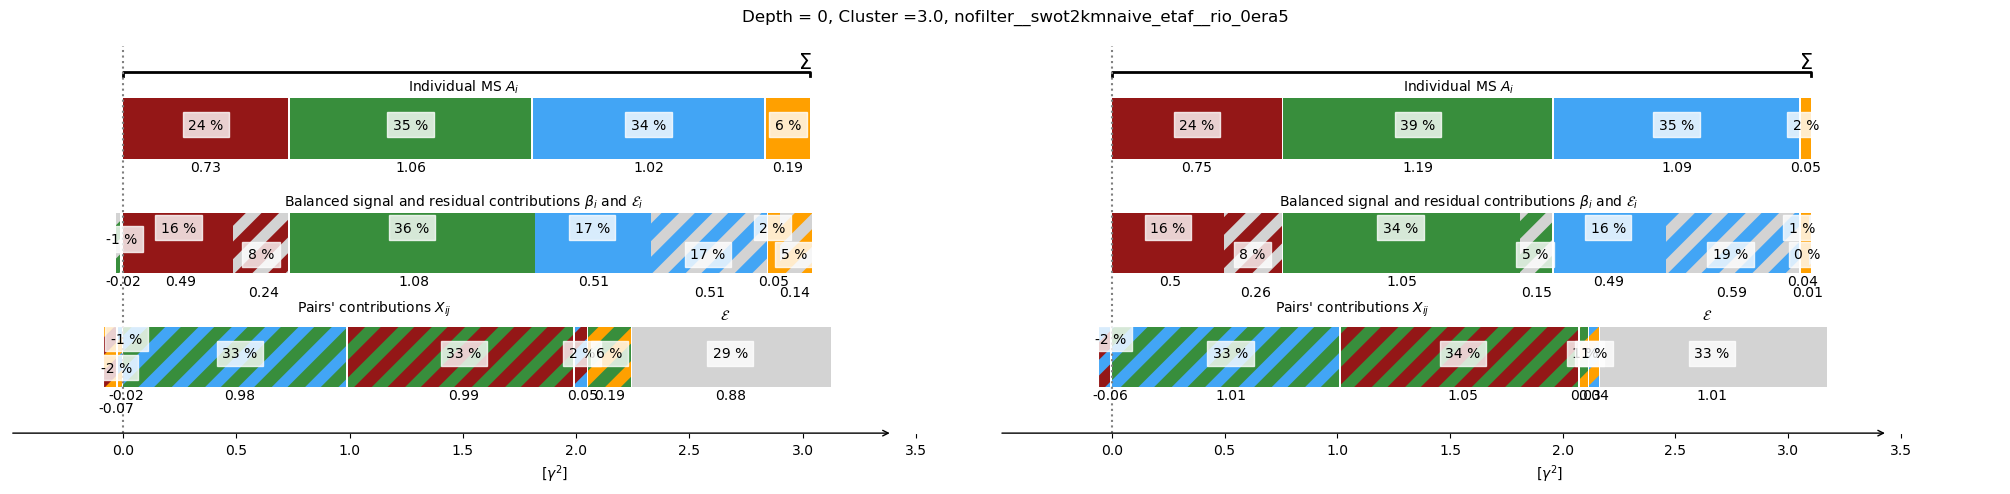

In [37]:
for c in Dmean : 
    df = Dmean[c].to_dataframe()
    print(D[c].sizes['row_number'])
    for idc in ds.id_comb.values :
        fig, axs = plt.subplots(nrows=1,ncols=2,figsize=(20,5), frameon=False)
        synthetic_figure(df.loc[idc], axs[0], dir='e')
        synthetic_figure(df.loc[idc], axs[1], dir='n')
        fig.suptitle(f'Depth = {depth}, Cluster ={c}, {idc}')
        fig.tight_layout()
        fig.savefig(os.path.join(images_dir, 'closure_figs', idc + '.png'))

In [85]:
c = np.array(dfc['cluster'].values).astype(str)
for i in np.arange(nc).astype(str) :
    c = np.where(c==i, color[int(i)], c)
dfc['color'] = c

In [45]:
color = {0:'teal', 1:'indigo', 2:'red', 3:'pink', 4:'orange'}

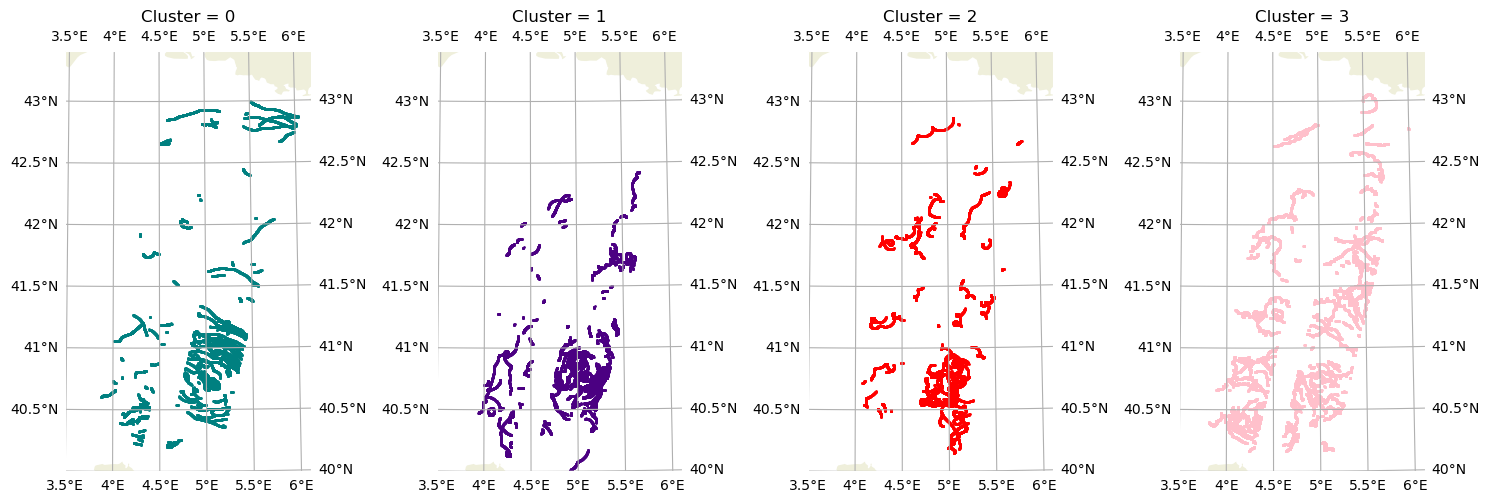

In [91]:
fig = plt.figure(figsize=(15,15), frameon=False)
#bbox =[2.7, 5.1, 36.6, 40]
#bbox = [0.9, 3.7, 37.7, 41.25]
bbox = [3.5, 6.1, 40, 43.4]
for i in range(nc) : 
    ax = fig.add_subplot(1,nc,i+1, projection=ccrs.Orthographic(dfc.longitude.mean(), dfc.latitude.mean()))
    dfc[dfc.cluster==i].plot.scatter(x='longitude', y='latitude',ax=ax, transform=crs, s=1, c=color[i])
    gl = ax.gridlines(draw_labels=True,)
    ax.add_feature(cfeature.LAND,)
    ax.set_extent(bbox)
    ax.set_title(f'Cluster = {i}')

fig.tight_layout()

Text(0.5, 0.92, 'Meridional')

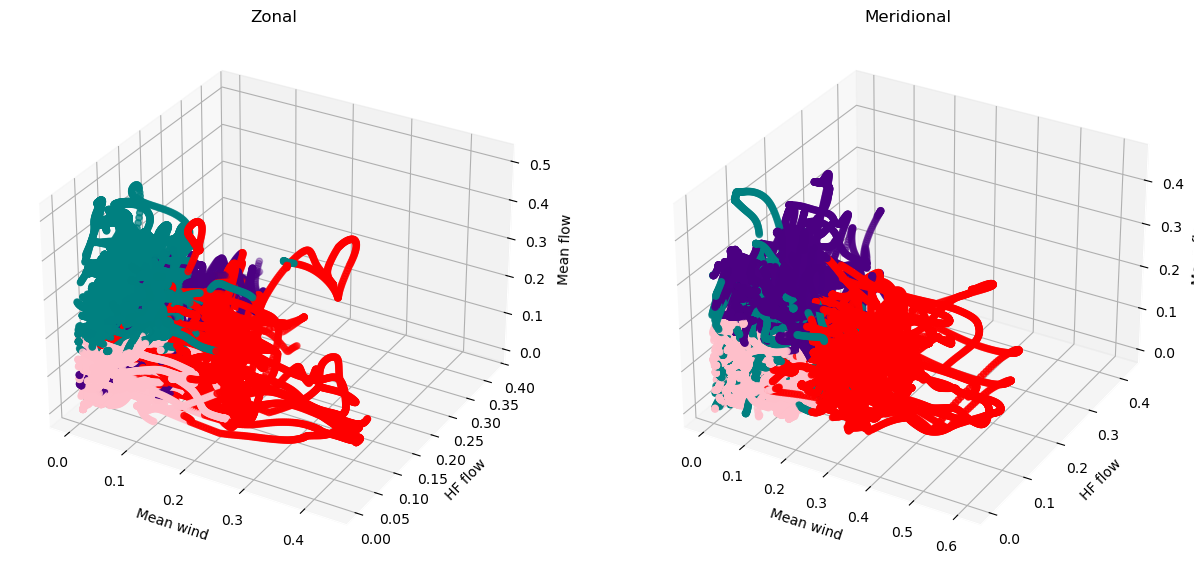

In [89]:
fig = plt.figure(figsize=(15,15), frameon=False)
ax = fig.add_subplot(121, projection='3d')
ax.scatter(xs=dfc.meanwinde, ys =dfc.hfe, zs=dfc.meanflowe, c=dfc.color)
ax.set_title('Zonal')
ax.set_xlabel('Mean wind')
ax.set_ylabel('HF flow')
ax.set_zlabel('Mean flow')
ax = fig.add_subplot(122, projection='3d')
ax.scatter(xs=dfc.meanwindn, ys =dfc.hfn, zs=dfc.meanflown, c=dfc.color)
ax.set_xlabel('Mean wind')
ax.set_ylabel('HF flow')
ax.set_zlabel('Mean flow')
ax.set_title('Meridional')
#fig.tight_layout()

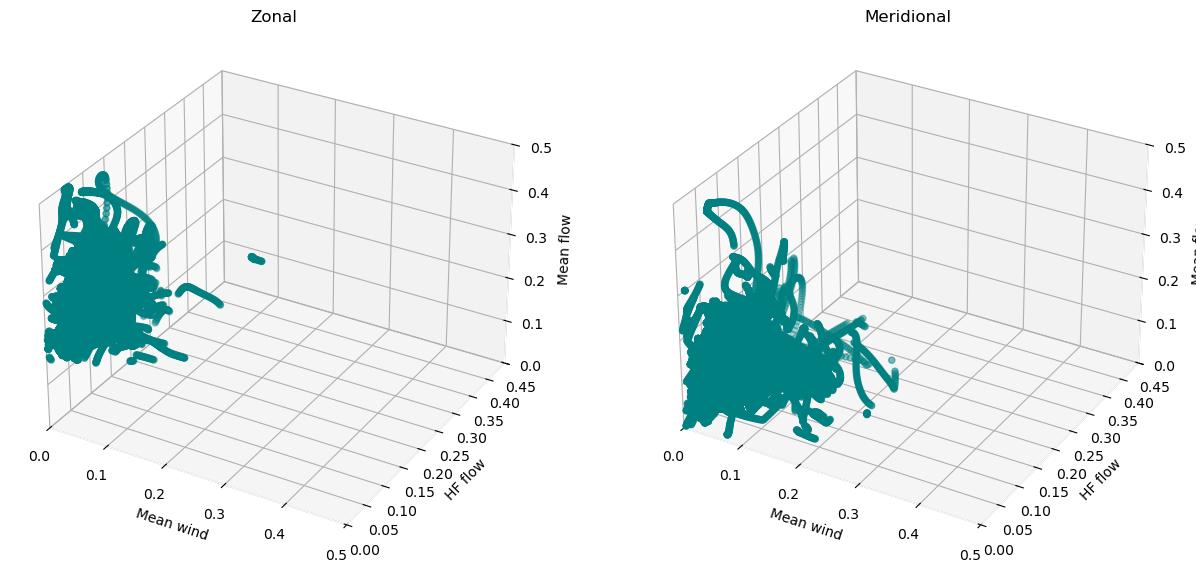

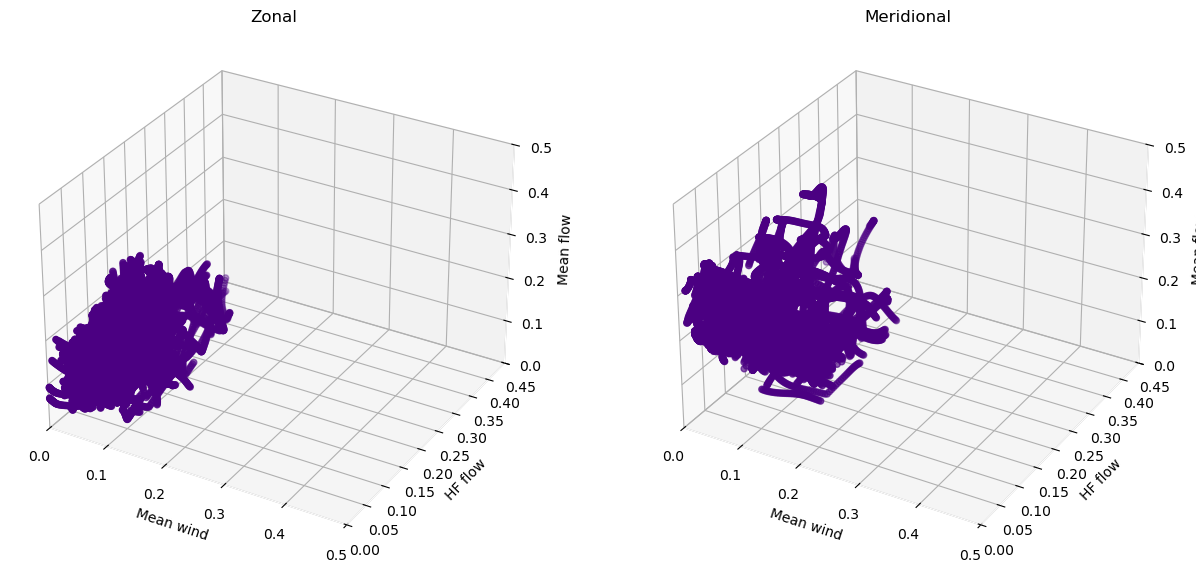

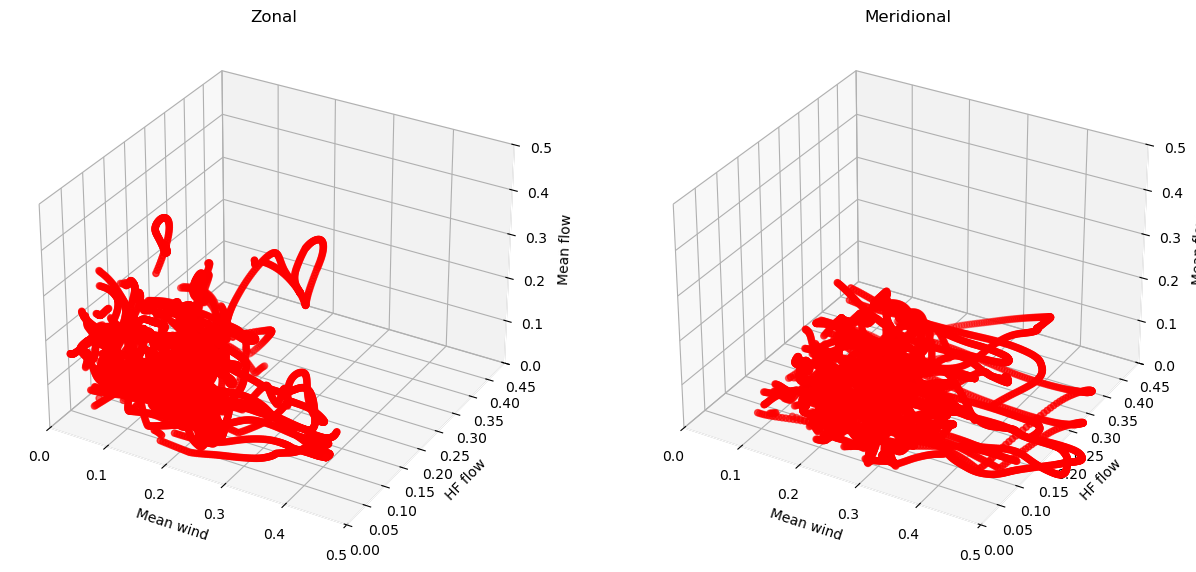

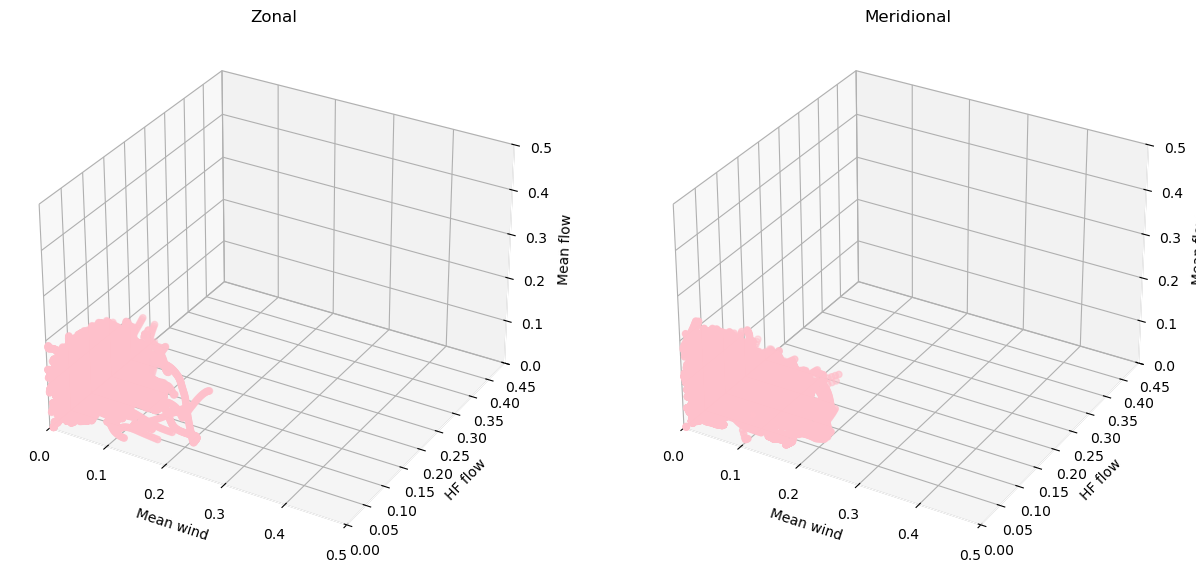

In [96]:
for c in range(4):
    dfc_ = dfc[dfc.cluster==c]
    fig = plt.figure(figsize=(15,15), frameon=False)
    ax = fig.add_subplot(121, projection='3d')
    ax.scatter(xs=dfc_.meanwinde, ys =dfc_.hfe, zs=dfc_.meanflowe, c=dfc_.color)
    ax.set_title('Zonal')
    ax.set_xlabel('Mean wind')
    ax.set_ylabel('HF flow')
    ax.set_zlabel('Mean flow')
    ax.set_xlim(0, 0.5)
    ax.set_ylim(0, 0.45)
    ax.set_zlim(0,0.5)

    ax = fig.add_subplot(122, projection='3d')
    ax.scatter(xs=dfc_.meanwindn, ys =dfc_.hfn, zs=dfc_.meanflown, c=dfc_.color)
    ax.set_xlabel('Mean wind')
    ax.set_ylabel('HF flow')
    ax.set_zlabel('Mean flow')
    
    ax.set_xlim(0, 0.5)
    ax.set_ylim(0, 0.45)
    ax.set_zlim(0,0.5)
    
    ax.set_title('Meridional')
    #fig.tight_layout()

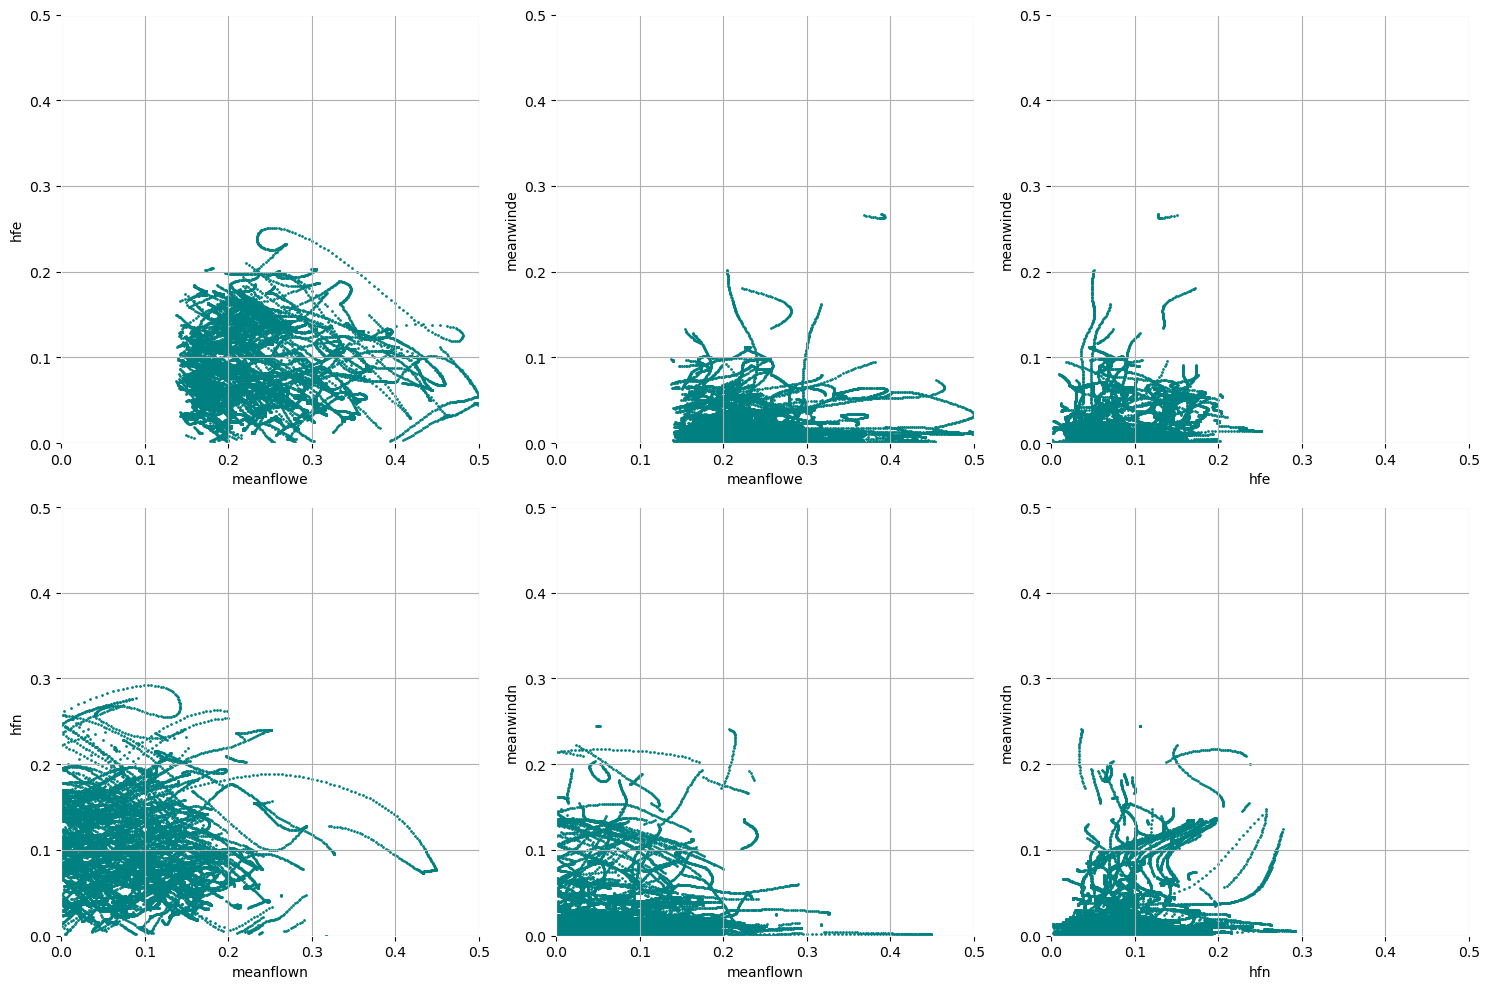

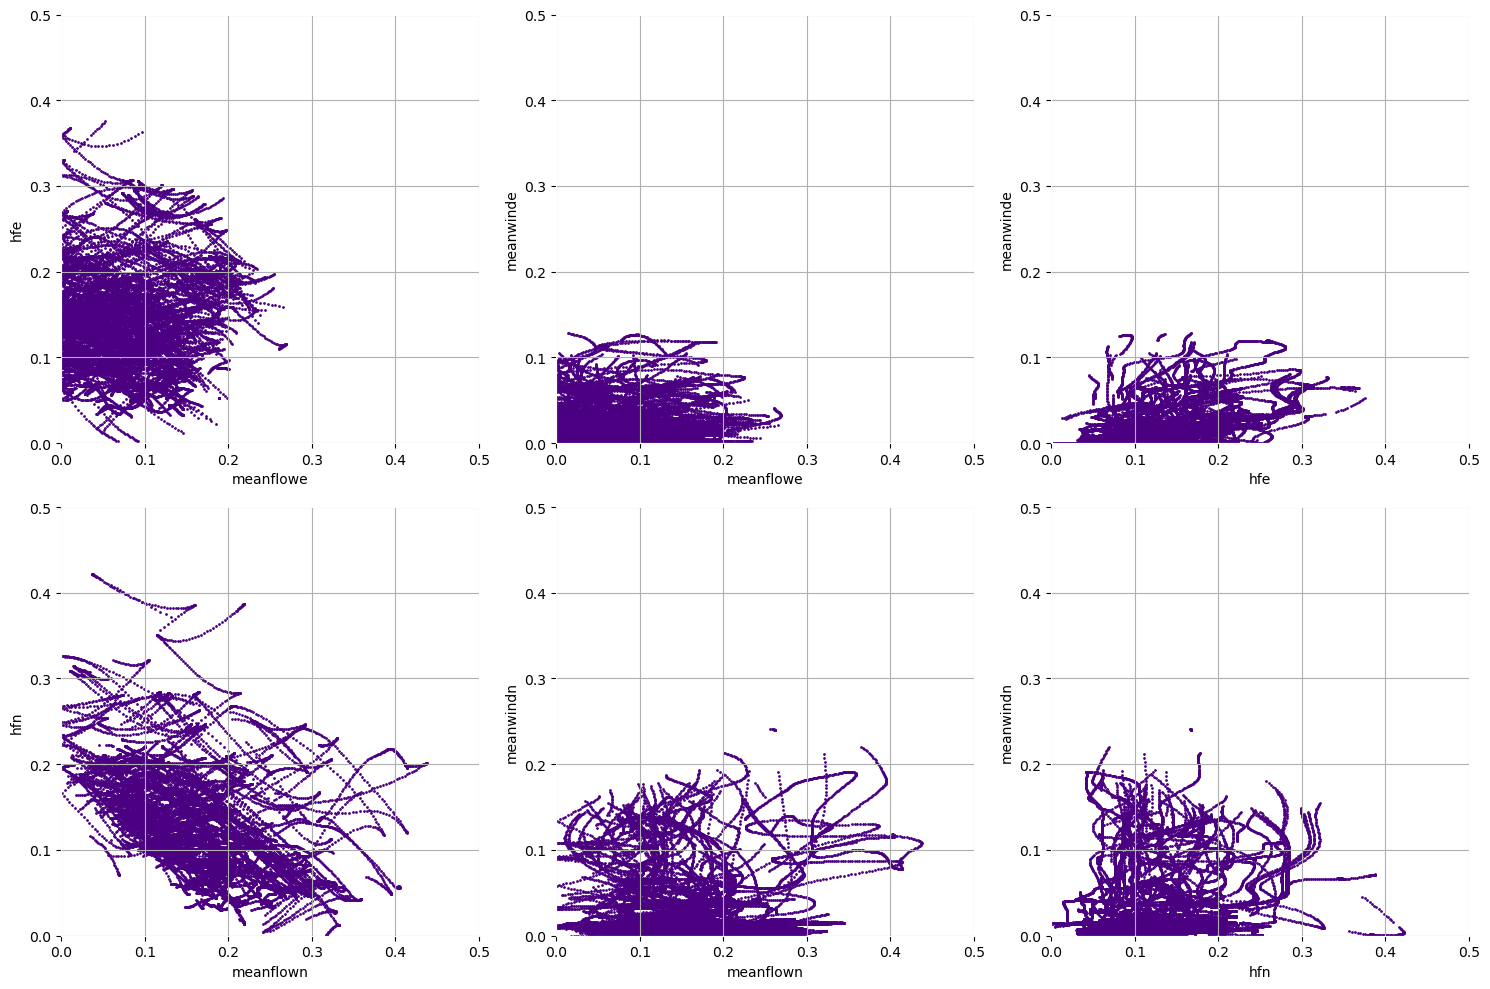

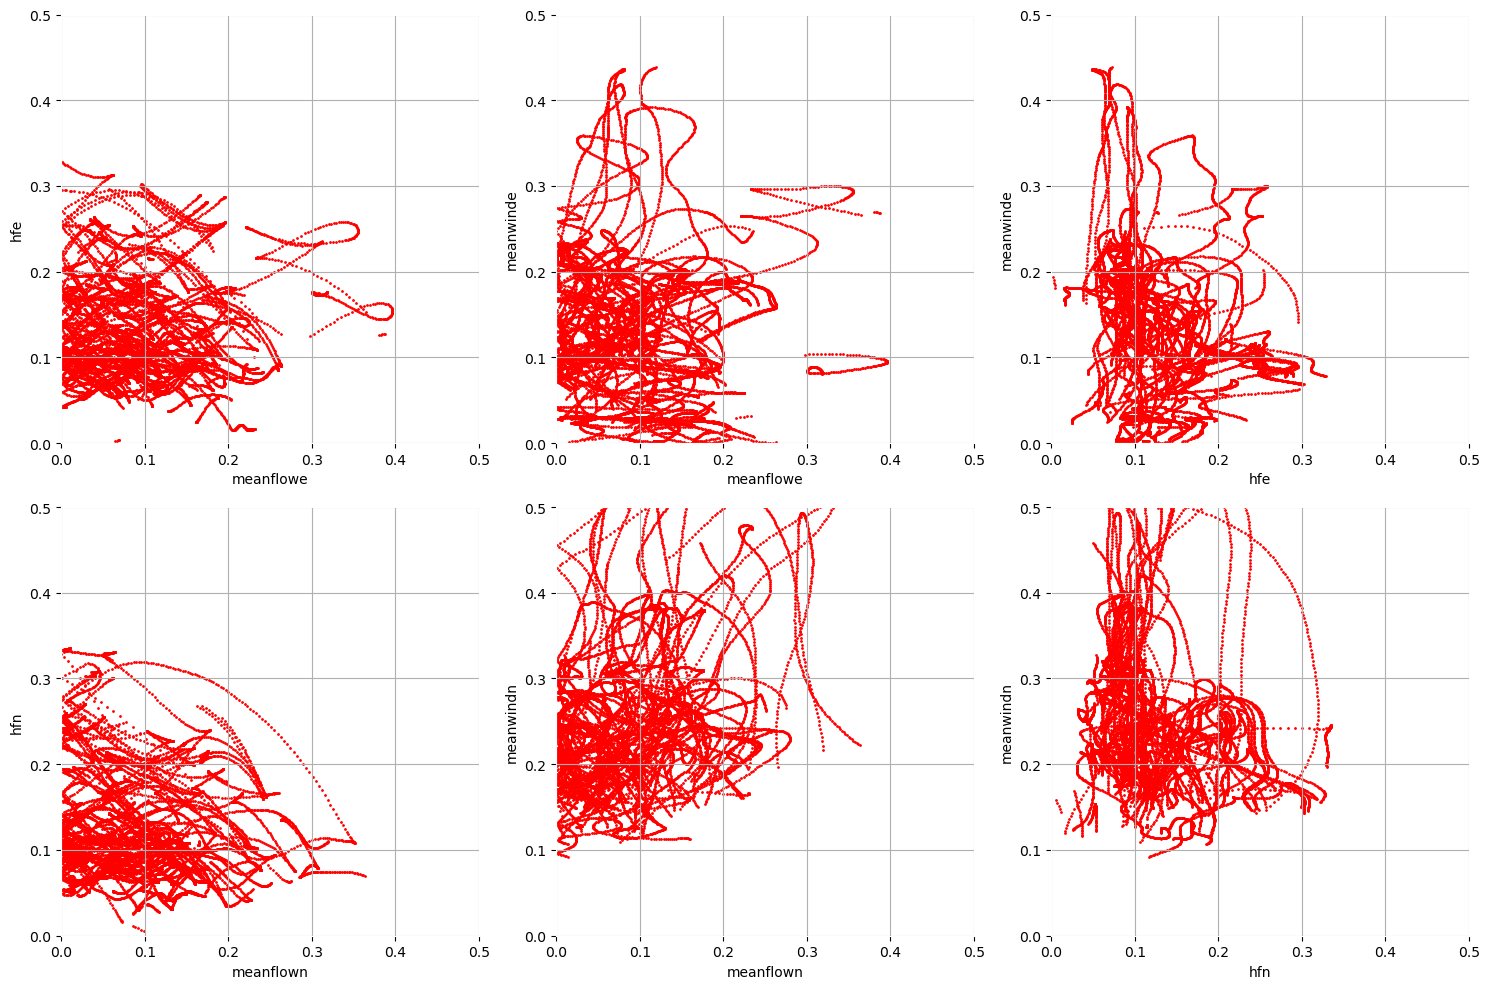

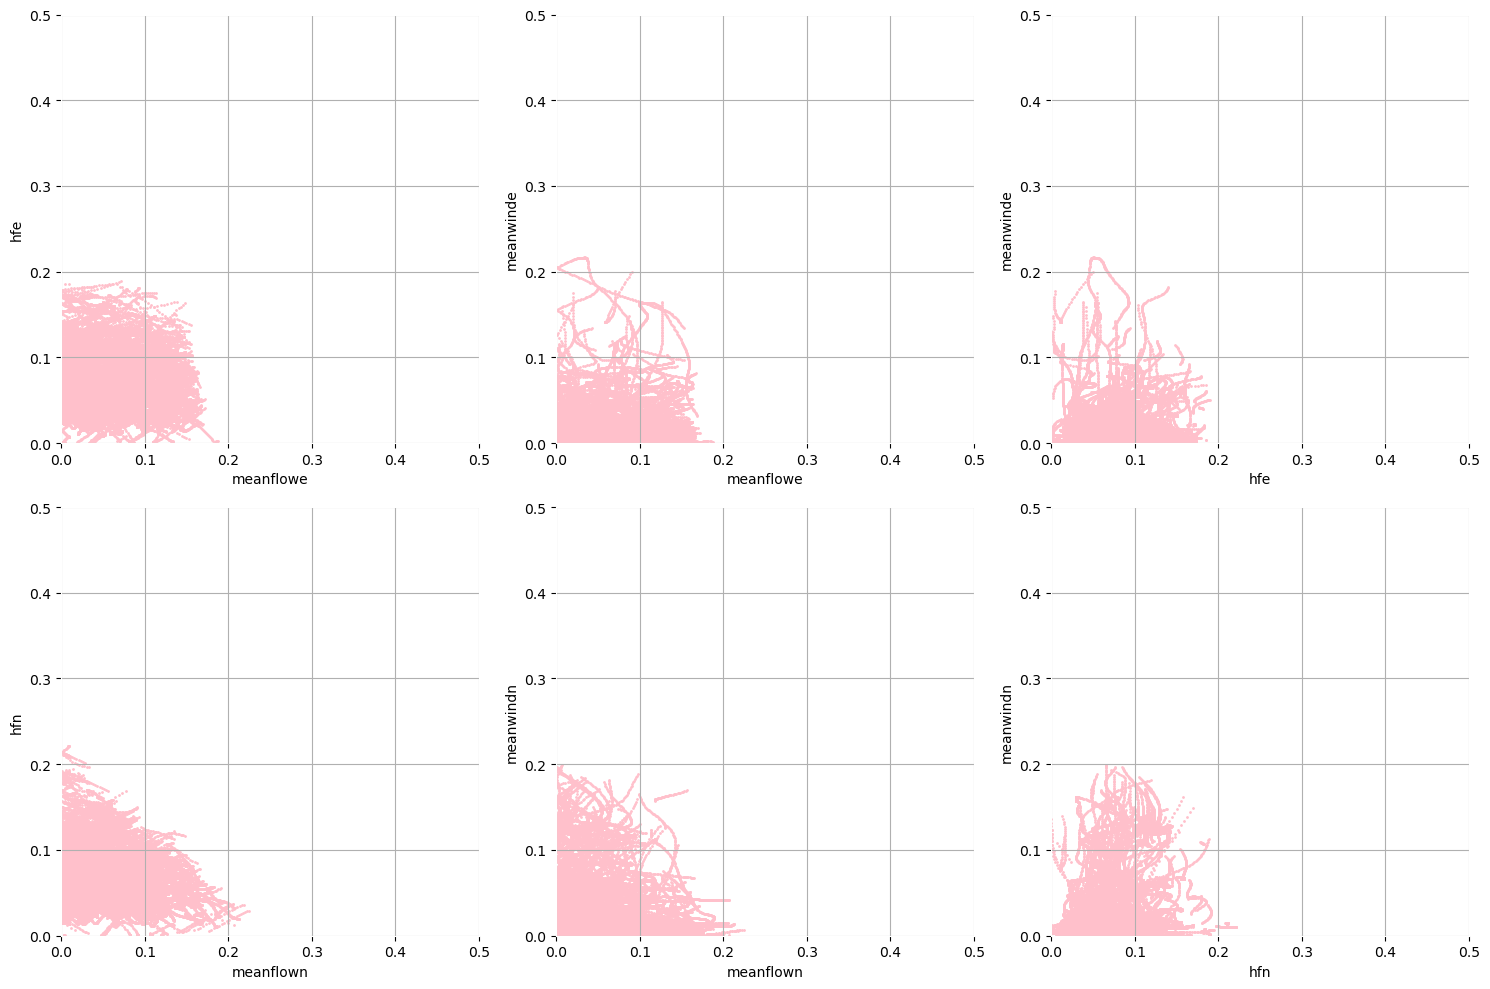

In [98]:
for c in range(4):
    dfc_ = dfc[dfc.cluster==c]
    fig, axs = plt.subplots(2,3, figsize=(15,10))
    axs = axs.flatten()
    s=1
    
    dfc_.plot.scatter('meanflowe', 'hfe', ax = axs[0], s=s, c=color[c])
    dfc_.plot.scatter('meanflowe', 'meanwinde', ax = axs[1], s=s, c=color[c])
    dfc_.plot.scatter('hfe', 'meanwinde', ax = axs[2], s=s, c=color[c])
    
    dfc_.plot.scatter('meanflown', 'hfn', ax = axs[3], s=s, c=color[c])
    dfc_.plot.scatter('meanflown', 'meanwindn', ax = axs[4], s=s, c=color[c])
    dfc_.plot.scatter('hfn', 'meanwindn', ax = axs[5], s=s, c=color[c])
    
    for ax in axs:
        ax.grid()
        ax.set_xlim(0,0.5)
        ax.set_ylim(0,0.5)
        
    fig.tight_layout()